# Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# load Dataset

In [25]:
df = pd.read_csv("airbnb_rental_data.csv")
df.head(5)



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20


# Initial Exploration

In [26]:
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
print(df.describe(include="all"))

rows = df.shape[0]
columns = df.shape[1]

print(f"\nThe dataset contains {rows} rows and {columns} columns.")


Dataset Shape:
(27379, 16)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27379 entries, 0 to 27378
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27379 non-null  int64  
 1   name                            27370 non-null  object 
 2   host_id                         27379 non-null  int64  
 3   host_name                       27369 non-null  object 
 4   neighbourhood_group             27379 non-null  object 
 5   neighbourhood                   27379 non-null  object 
 6   latitude                        27379 non-null  float64
 7   longitude                       27379 non-null  float64
 8   room_type                       27379 non-null  object 
 9   price                           27379 non-null  int64  
 10  minimum_nights                  27379 non-null  int64  
 11  number_of_reviews               27379 non-n

# Data Quality Assessment

In [27]:
# Check for missing values
print("\nMissing Values:")
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])


# Check for duplicated rows
duplicates = df.duplicated().sum()

print("\nNumber of Duplicated Rows:")
print(duplicates)


# Remove duplicated rows
if duplicates > 0:
    df = df.drop_duplicates()

    print(
        f"\n{duplicates} duplicated rows were removed."
    )
else:
    print("\nNo duplicated rows were found.")



Missing Values:
name                    9
host_name              10
last_review          5633
reviews_per_month    5633
dtype: int64

Number of Duplicated Rows:
0

No duplicated rows were found.


# 5. Drop Irrelevant Columns
These columns mainly contain identifiers, names, or date information that will not be directly used by the current regression model.

In [28]:
columns_to_drop = [
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review"
]

# Only remove columns that actually exist in the dataset
columns_to_drop = [
    column
    for column in columns_to_drop
    if column in df.columns
]

df = df.drop(columns=columns_to_drop)

print("\nColumns After Removing Irrelevant Features:")
print(df.columns.tolist())


Columns After Removing Irrelevant Features:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


# 6. Exploratory Data Analysis

6.1 Price Summary

In [29]:
# Analyze the price distribution
print("\nPrice Summary Statistics:")
print(df["price"].describe())

# Analyze the skewness of the price distribution
print("\nPrice Skewness:")
print(df["price"].skew())



Price Summary Statistics:
count    27379.000000
mean       151.569561
std        219.807784
min          0.000000
25%         69.000000
50%        105.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Price Skewness:
16.53261303867021


6.2 Price Distribution

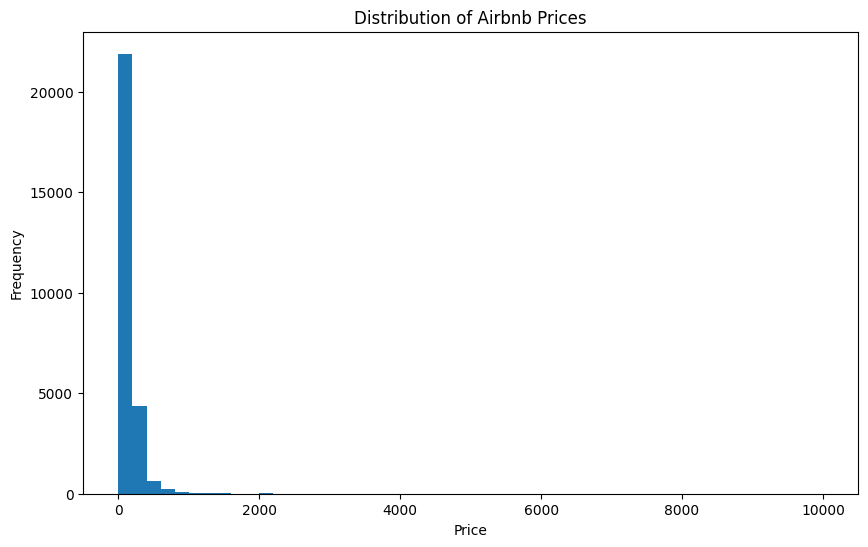

In [30]:
# Visualize the price distribution
plt.figure(figsize=(10, 6))

plt.hist(
    df["price"],
    bins=50,
)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Airbnb Prices")

plt.show()

6.3 Zoomed Price Distribution

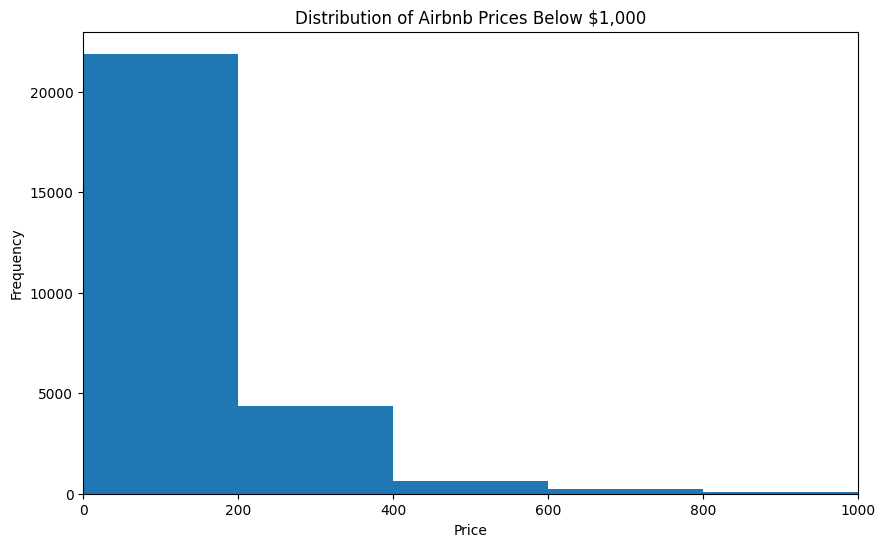

In [31]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["price"],
    bins=50
)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Airbnb Prices Below $1,000")

plt.xlim(0, 1000)

plt.show()

6.4 Price Boxplot

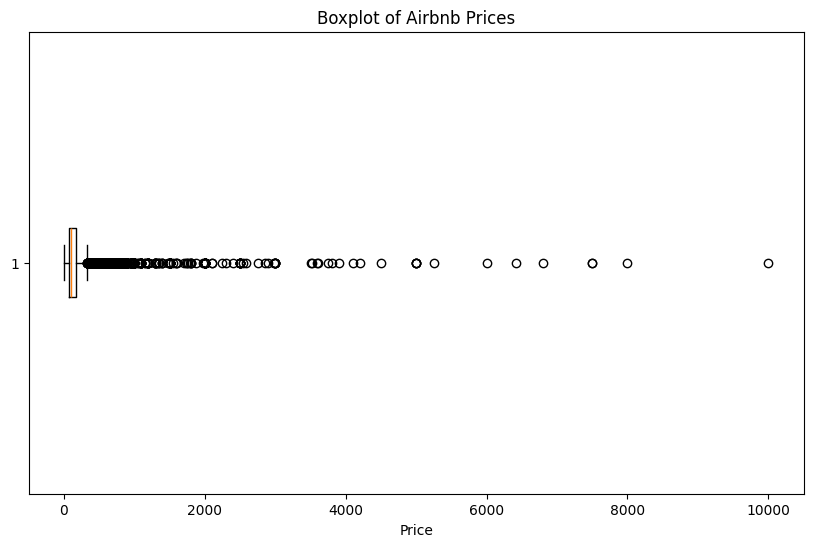

In [32]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    df["price"],
    vert=False
)

plt.xlabel("Price")
plt.title("Boxplot of Airbnb Prices")

plt.show()


6.5 Outlier Detection with IQR

In [33]:
# Function to check for outliers using the IQR method on a specific column
def check_outliers(dataframe, column):
    
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outliers = dataframe[
        (dataframe[column] < lower_bound)
        | (dataframe[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound


price_outliers, lower_bound, upper_bound = check_outliers(
    df,
    "price"
)

print("\nPrice Outlier Analysis:")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Number of Price Outliers: {len(price_outliers)}")

outlier_percentage = (
    len(price_outliers) / len(df)
) * 100

print(
    f"Percentage of Price Outliers: "
    f"{outlier_percentage:.2f}%"
)


Price Outlier Analysis:
Lower Bound: -90.00
Upper Bound: 334.00
Number of Price Outliers: 1659
Percentage of Price Outliers: 6.06%


6.6 Median Price by Room Type

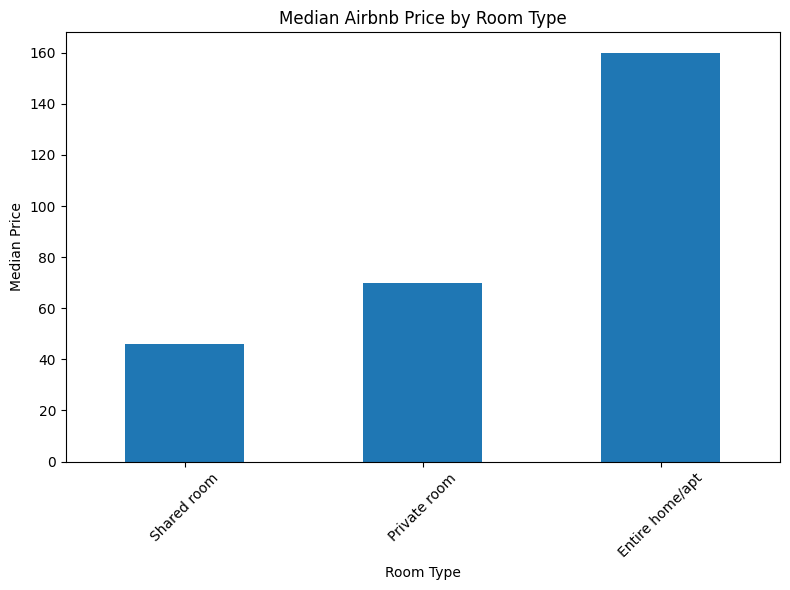

In [34]:
# Visualize the median price by room type
if "room_type" in df.columns:

    room_type_price = (
        df.groupby("room_type")["price"]
        .median()
        .sort_values()
    )

    plt.figure(figsize=(8, 6))

    room_type_price.plot(
        kind="bar"
    )

    plt.xlabel("Room Type")
    plt.ylabel("Median Price")
    plt.title("Median Airbnb Price by Room Type")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


6.7 Median Price by Neighbourhood Group

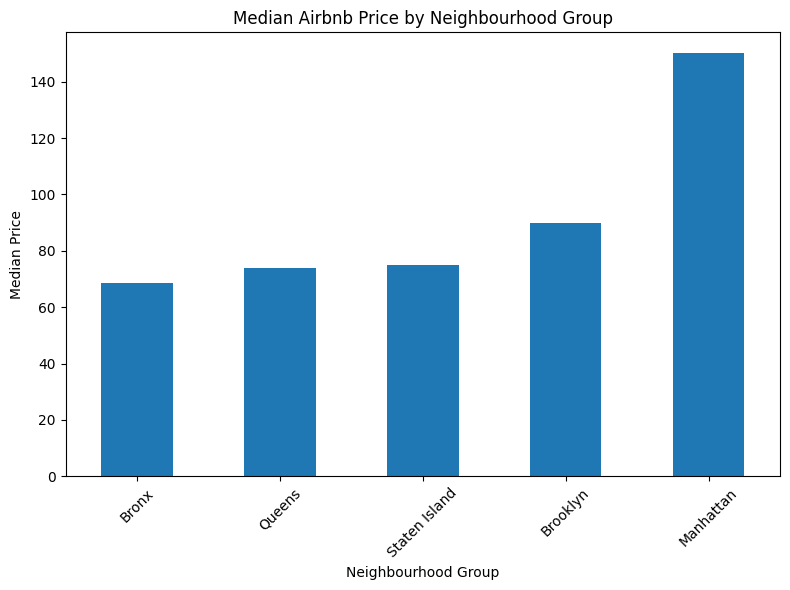

In [35]:
# Visualize the median price by neighbourhood group
if "neighbourhood_group" in df.columns:

    neighbourhood_group_price = (
        df.groupby("neighbourhood_group")["price"]
        .median()
        .sort_values()
    )

    plt.figure(figsize=(8, 6))

    neighbourhood_group_price.plot(
        kind="bar"
    )

    plt.xlabel("Neighbourhood Group")
    plt.ylabel("Median Price")
    plt.title(
        "Median Airbnb Price by Neighbourhood Group"
    )

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# 7. Define Feature and Target

In [36]:
# Choose Price as the target variable and the rest as features
X = df.drop(columns="price")
y = df["price"]


print("\nFeature Dataset Shape:")
print(X.shape)

print("\nTarget Dataset Shape:")
print(y.shape)


Feature Dataset Shape:
(27379, 10)

Target Dataset Shape:
(27379,)


# 8. Split Data into Training, Validation and Test Sets

In [37]:
# First split:
# 80% temporary training data
# 20% test data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Second split:
# 75% of temporary training data = 60% total training data
# 25% of temporary training data = 20% total validation data

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42
)


print("\nDataset Split:")
print(f"Training Set:   {X_train.shape}")
print(f"Validation Set: {X_val.shape}")
print(f"Test Set:       {X_test.shape}")



Dataset Split:
Training Set:   (16427, 10)
Validation Set: (5476, 10)
Test Set:       (5476, 10)


# 9. Identify Numerical and Categorical Features

In [38]:
# Select numerical features from the training set
numerical_features = X_train.select_dtypes(
    include=["int64", "float64", "number"]
).columns.tolist()

## Select categorical features from the training set
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()


print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)



Numerical Features:
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Categorical Features:
['neighbourhood_group', 'neighbourhood', 'room_type']


# 10. Create Preprocessing Pipelines

10.1 Numerical Pipeline

In [39]:
# Missing numerical values are replaced with the median.
# Numerical features are then standardized.

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


10.2 Categorical Pipeline

In [40]:
# Missing categorical values are replaced with the most
# frequent category.
# One-hot encoding converts categorical features into
# numerical binary features.

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# 11. Combine Preprocessing Pipelines

In [41]:
# The ColumnTransformer applies the appropriate preprocessing
# pipeline to the corresponding feature types (numerical or categorical).
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

# 12. Regression Evaluation Function

In [42]:
# Calculate and display common regression evaluation metrics.
def evaluate_regression(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"MAE:  {mae:.2f}")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }



# 13. Baseline Linear Regression Model

In [43]:
# Create a pipeline that combines the preprocessing steps and the linear regression model.
standard_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

# Train the baseline model
standard_model.fit(
    X_train,
    y_train
)

# Validation predictions
standard_val_pred = standard_model.predict(
    X_val
)

print(
    "\n============================================"
)

print(
    "STANDARD LINEAR REGRESSION - VALIDATION SET"
)

print(
    "============================================"
)

# Evaluate the model on the validation set
standard_results = evaluate_regression(
    y_val,
    standard_val_pred
)



STANDARD LINEAR REGRESSION - VALIDATION SET
MAE:  71.31
MSE:  42261.11
RMSE: 205.58
R²:   0.1156


# 14. Linear Regression with Log Target Transformation
The price distribution contains extreme values and is positively skewed. A logarithmic transformation is tested to reduce the influence of very large target values.

In [44]:
# Create a pipeline that combines the preprocessing steps and the log-transformed linear regression model.
log_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            TransformedTargetRegressor(
                regressor=LinearRegression(),
                func=np.log1p,
                inverse_func=np.expm1
            )
        )
    ]
)

# Train the log-transformed model
log_model.fit(
    X_train,
    y_train
)

# Validation predictions
log_val_pred = log_model.predict(
    X_val
)

print(
    "\n============================================"
)

print(
    "LOG-TRANSFORMED LINEAR REGRESSION - "
    "VALIDATION SET"
)

print(
    "============================================"
)

# Evaluate the log-transformed model on the validation set
log_results = evaluate_regression(
    y_val,
    log_val_pred
)



LOG-TRANSFORMED LINEAR REGRESSION - VALIDATION SET
MAE:  60.05
MSE:  42479.29
RMSE: 206.11
R²:   0.1110


# 15. Compare Models

In [45]:
# Create a DataFrame to compare the evaluation metrics of both models
model_comparison = pd.DataFrame(
    {
        "Model": [
            "Standard Linear Regression",
            "Log-Transformed Linear Regression"
        ],
        "MAE": [
            standard_results["MAE"],
            log_results["MAE"]
        ],
        "MSE": [
            standard_results["MSE"],
            log_results["MSE"]
        ],
        "RMSE": [
            standard_results["RMSE"],
            log_results["RMSE"]
        ],
        "R2": [
            standard_results["R2"],
            log_results["R2"]
        ]
    }
)


print("\nModel Comparison:")
print(model_comparison)



Model Comparison:
                               Model        MAE           MSE        RMSE  \
0         Standard Linear Regression  71.310134  42261.108718  205.575068   
1  Log-Transformed Linear Regression  60.051896  42479.286995  206.105039   

         R2  
0  0.115577  
1  0.111011  


# 16. Visualize Model Comparision

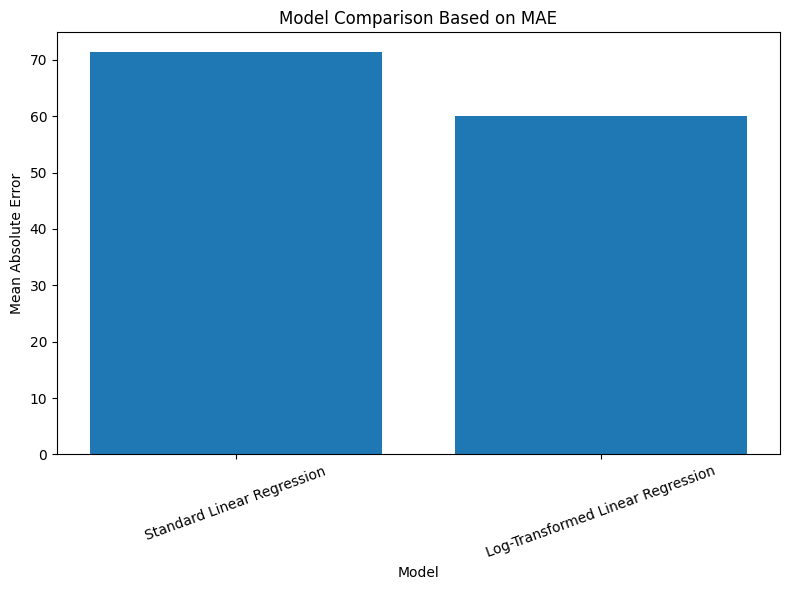

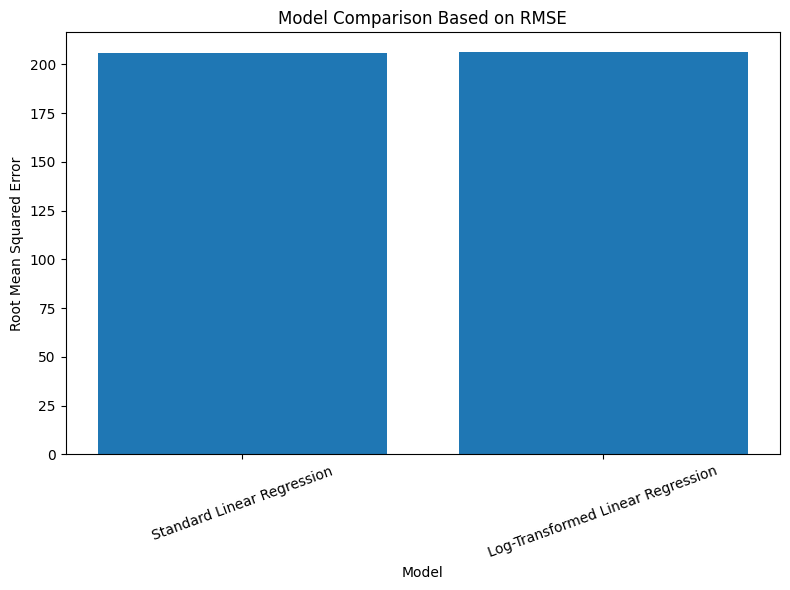

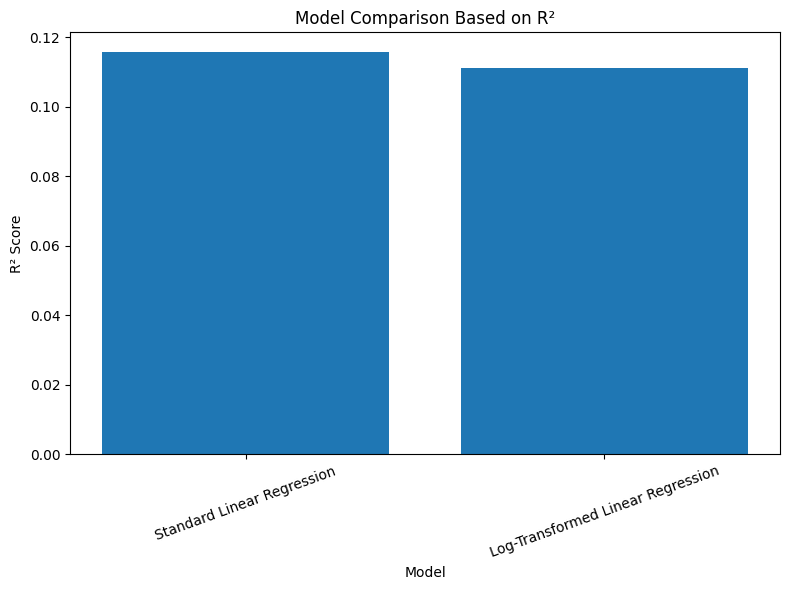

In [46]:
# Create bar plots to visualize the comparison of evaluation metrics between the two models
plt.figure(figsize=(8, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.title("Model Comparison Based on MAE")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


plt.figure(figsize=(8, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")
plt.title("Model Comparison Based on RMSE")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


plt.figure(figsize=(8, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison Based on R²")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

# 17. Select Best Model
The model with the lower validation RMSE is selected.

In [47]:
# Check which model has the lower RMSE and select it as the best model
if (log_results["RMSE"] < standard_results["RMSE"]):

    best_model = log_model
    best_model_name = (
        "Log-Transformed Linear Regression"
    )

else:

    best_model = standard_model
    best_model_name = (
        "Standard Linear Regression"
    )


print("\nSelected Model:")
print(best_model_name)



Selected Model:
Standard Linear Regression


# 18. Evaluate the Selected Model on the Test Set
The test set is only used for the final model evaluation.

In [48]:
# Create predictions on the test set using the selected best model
y_test_pred = best_model.predict(
    X_test
)


print(
    "\n============================================"
)

print(
    f"FINAL TEST RESULTS - {best_model_name}"
)

print(
    "============================================"
)


test_results = evaluate_regression(
    y_test,
    y_test_pred
)



FINAL TEST RESULTS - Standard Linear Regression
MAE:  68.71
MSE:  26312.83
RMSE: 162.21
R²:   0.1660


# 19. Actual vs. Predicted Price Visualization

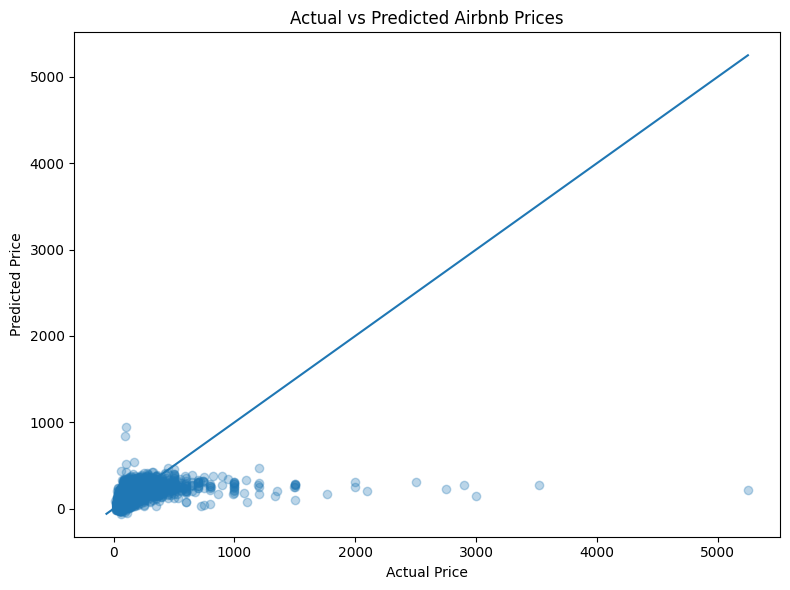

In [49]:
# Create a scatter plot to visualize the relationship between actual and predicted prices on the test set
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.3
)

# Get the minimum values
minimum_price = min(
    y_test.min(),
    y_test_pred.min()
)
# Get the maximum values
maximum_price = max(
    y_test.max(),
    y_test_pred.max()
)

# Plot a diagonal line representing perfect predictions
plt.plot(
    [
        minimum_price,
        maximum_price
    ],
    [
        minimum_price,
        maximum_price
    ]
)


plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Airbnb Prices"
)

plt.tight_layout()

plt.show()


# 20. Residual Analysis

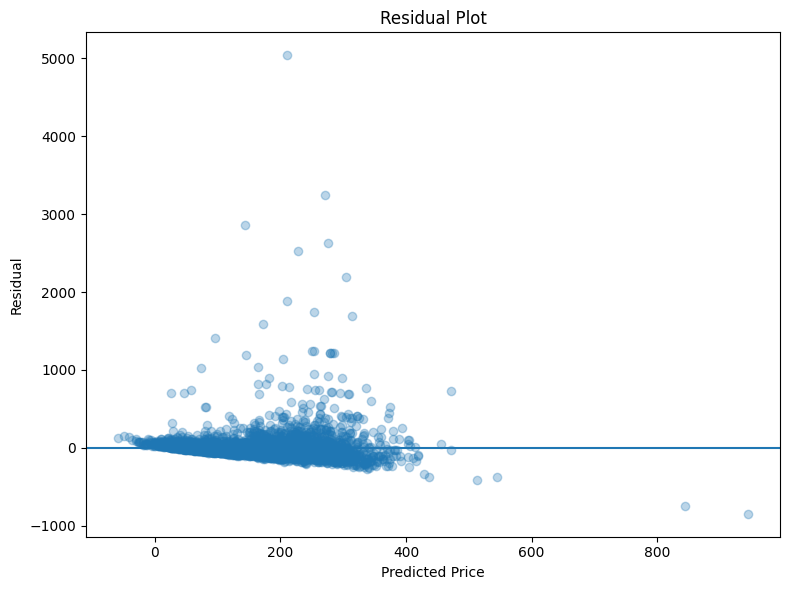

In [50]:
# Residual is the difference between the actual and predicted prices. 
# It helps to assess the model's performance and identify any patterns or biases in the predictions.
residuals = (
    y_test - y_test_pred
)


plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title(
    "Residual Plot"
)

plt.tight_layout()

plt.show()

# 21. Residual Distribution

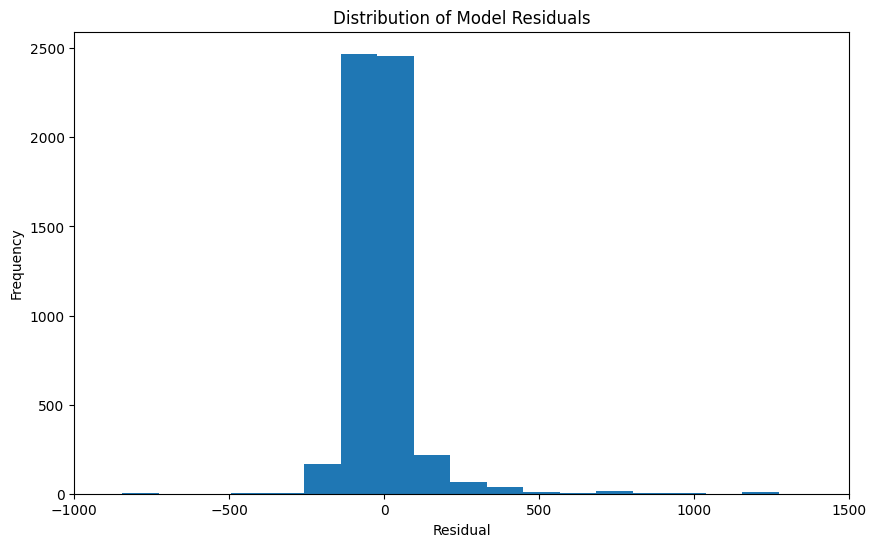

In [51]:
# Plot the distribution of model residuals
plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=50
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.xlim(-1000, 1500)

plt.title(
    "Distribution of Model Residuals"
)

plt.show()

# 22. Display Sample Predictions

In [52]:
# Create a DataFrame to display the actual prices, predicted prices, and absolute errors for the test set
prediction_results = pd.DataFrame(
    {
        "Actual Price": y_test.values,
        "Predicted Price": y_test_pred
    }
)

# Calculate the absolute error for each prediction
prediction_results["Absolute Error"] = np.abs(
    prediction_results["Actual Price"]
    - prediction_results["Predicted Price"]
)


print("\nSample Predictions:")
print(
    prediction_results.head(10)
)


Sample Predictions:
   Actual Price  Predicted Price  Absolute Error
0           150       197.007139       47.007139
1            65        34.021144       30.978856
2            90       108.831917       18.831917
3            55        92.477070       37.477070
4           225       222.878964        2.121036
5            50        88.620321       38.620321
6           138       240.166133      102.166133
7            99       131.823593       32.823593
8           160       205.598390       45.598390
9            90       166.488743       76.488743


# 23. Final Result Summery

In [53]:
print(
    "\n============================================"
)

print(
    "FINAL MODEL SUMMARY"
)

print(
    "============================================"
)

print(
    f"Selected Model: {best_model_name}"
)

print(
    f"Test MAE:  {test_results['MAE']:.2f}"
)

print(
    f"Test MSE:  {test_results['MSE']:.2f}"
)

print(
    f"Test RMSE: {test_results['RMSE']:.2f}"
)

print(
    f"Test R²:   {test_results['R2']:.4f}"
)


FINAL MODEL SUMMARY
Selected Model: Standard Linear Regression
Test MAE:  68.71
Test MSE:  26312.83
Test RMSE: 162.21
Test R²:   0.1660
